In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import joblib
import os

from xgboost import XGBClassifier

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/processed/features.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (23376, 170)


In [3]:
df.head()

,interval_start,equipment_ID,count_sum,A_028,A_029,A_024,A_045,A_001,A_058,A_064,...,A_053,A_054,A_060,A_061,production_rolling_6h,downtime_rolling_6h,production_change,downtime_change,performance_change,health_score
0,2020-01-01 14:00:00,s_1,4,0.0,0,0,NaN,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,0.861729,0.052261,0.000000,0.000000,0.000000,99.906124
1,2020-01-01 15:00:00,s_1,2,0.0,0,0,NaN,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,0.866313,0.084982,0.009168,0.065443,-0.008692,99.870897
2,2020-01-01 17:00:00,s_1,1,0.0,0,0,NaN,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,0.903703,0.063827,0.107586,-0.096186,-0.011399,99.978483
3,2020-01-01 18:00:00,s_1,4,0.0,0,0,NaN,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,0.795544,0.164966,-0.507417,0.446867,0.000000,99.531616
4,2020-01-01 19:00:00,s_1,1,0.0,0,0,NaN,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,0.833840,0.133529,0.515958,-0.460606,0.005198,99.987024


In [4]:
df.tail()

,interval_start,equipment_ID,count_sum,A_028,A_029,A_024,A_045,A_001,A_058,A_064,...,A_053,A_054,A_060,A_061,production_rolling_6h,downtime_rolling_6h,production_change,downtime_change,performance_change,health_score
23371,2022-01-01 06:00:00,s_5,1,NaN,0,0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.954908,0.012467,-0.056098,0.030375,0.038370,99.859253
23372,2022-01-01 08:00:00,s_5,1,NaN,0,0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.956722,0.011430,0.127154,-0.018750,-0.108404,99.986407
23373,2022-01-01 10:00:00,s_5,2,NaN,0,0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.891305,0.040122,-0.392206,0.171850,0.220355,99.594201
23374,2022-01-01 11:00:00,s_5,1,NaN,0,0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.889083,0.042344,0.390567,-0.170211,-0.220355,99.984768
23375,2022-01-01 12:00:00,s_5,1,NaN,0,0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.883991,0.047435,-0.020801,0.020801,0.000000,99.963967


In [5]:
print("Number of columns:", len(df.columns))

for column in df.columns:
    print(column)

Number of columns: 170
interval_start
equipment_ID
count_sum
A_028
A_029
A_024
A_045
A_001
A_058
A_064
A_030
A_101
A_002
A_107
A_056
A_015
A_032
A_026
A_003
A_008
A_078
A_070
A_004
A_005
A_009
A_016
A_010
A_027
A_020
A_017
A_048
A_022
A_011
A_012
A_013
A_042
A_023
A_034
A_036
A_079
A_077
A_090
A_021
A_049
A_006
#changes
%idle
%production
%downtime
%performance_loss
%scheduled_downtime
idle/idle
idle/production
idle/downtime
idle/performance_loss
idle/scheduled_downtime
production/idle
production/production
production/downtime
production/performance_loss
production/scheduled_downtime
downtime/idle
downtime/production
downtime/downtime
downtime/performance_loss
downtime/scheduled_downtime
performance_loss/idle
performance_loss/production
performance_loss/downtime
performance_loss/performance_loss
performance_loss/scheduled_downtime
scheduled_downtime/idle
scheduled_downtime/production
scheduled_downtime/downtime
scheduled_downtime/performance_loss
scheduled_downtime/scheduled_downtime
A_

In [6]:
required_columns = [
    "equipment_ID",
    "interval_start",
    "%production",
    "%downtime",
    "%idle",
    "%performance_loss",
    "%scheduled_downtime",
    "#changes",
    "production_rolling_6h",
    "downtime_rolling_6h",
    "production_change",
    "downtime_change",
    "performance_change",
    "health_score"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    print("Missing columns:")
    print(missing_columns)
else:
    print("All required columns are available.")

All required columns are available.


In [7]:
df["interval_start"] = pd.to_datetime(
    df["interval_start"],
    errors="coerce"
)

print(df["interval_start"].dtype)

datetime64[us]


In [8]:
print(
    "Missing dates:",
    df["interval_start"].isna().sum()
)

Missing dates: 0


In [9]:
df = df.sort_values(
    ["equipment_ID", "interval_start"]
).reset_index(drop=True)

print("Data sorted by machine and time.")

Data sorted by machine and time.


In [10]:
print("Start date:")
print(df["interval_start"].min())

print("\nEnd date:")
print(df["interval_start"].max())

Start date:
2020-01-01 01:00:00

End date:
2022-01-01 23:00:00


In [12]:
print(
    "Number of machines:",
    df["equipment_ID"].nunique()
)

print("\nMachines:")
print(
    df["equipment_ID"].unique()
)

Number of machines: 5

Machines:
<ArrowStringArray>
['s_1', 's_2', 's_3', 's_4', 's_5']
Length: 5, dtype: str


In [13]:
operational_columns = [
    "%production",
    "%downtime",
    "%idle",
    "%performance_loss"
]

df[operational_columns].describe()

,%production,%downtime,%idle,%performance_loss
count,23376.000000,23376.000000,23376.000000,23376.000000
mean,0.631779,0.132762,0.068730,0.131189
std,0.279628,0.162798,0.160961,0.169048
min,0.000000,0.000438,0.000000,0.000000
25%,0.456896,0.029329,0.000000,0.005837
50%,0.702421,0.078096,0.000000,0.067561
75%,0.857945,0.171148,0.049836,0.184372
max,0.999512,1.000000,0.996116,0.992402


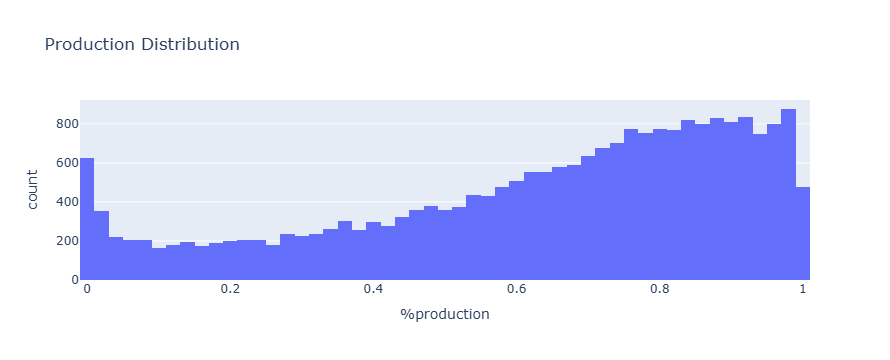

In [14]:
fig = px.histogram(
    df,
    x="%production",
    nbins=50,
    title="Production Distribution"
)

fig.show()

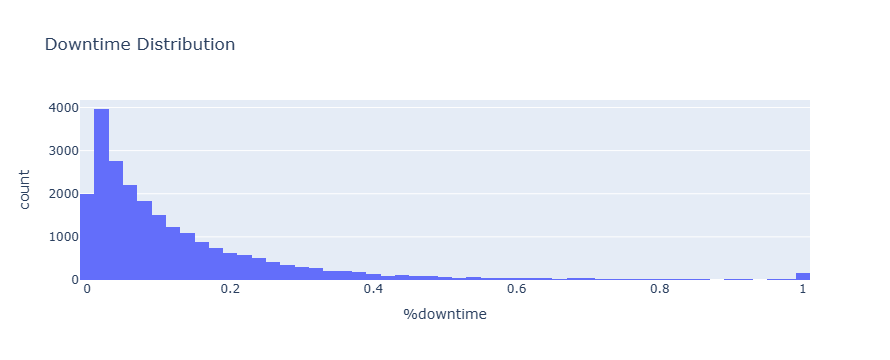

In [15]:
fig = px.histogram(
    df,
    x="%downtime",
    nbins=50,
    title="Downtime Distribution"
)

fig.show(

In [17]:
df = df.copy()

print("DataFrame optimized successfully.")
print("Shape:", df.shape)

DataFrame optimized successfully.
Shape: (23376, 171)


In [18]:
df["future_production"] = (
    df.groupby("equipment_ID")["%production"]
    .shift(-6)
)

In [19]:
df["future_downtime"] = (
    df.groupby("equipment_ID")["%downtime"]
    .shift(-6)
)

In [20]:
df["future_performance_loss"] = (
    df.groupby("equipment_ID")["%performance_loss"]
    .shift(-6)
)

In [21]:
df[
    [
        "equipment_ID",
        "interval_start",
        "%production",
        "future_production",
        "%downtime",
        "future_downtime",
        "%performance_loss",
        "future_performance_loss"
    ]
].head(20)

,equipment_ID,interval_start,%production,future_production,%downtime,future_downtime,%performance_loss,future_performance_loss
0,s_1,2020-01-01 14:00:00,0.861729,0.372573,0.052261,0.627427,0.020092,0.000000
1,s_1,2020-01-01 15:00:00,0.870897,0.711500,0.117704,0.220845,0.011399,0.002757
2,s_1,2020-01-01 17:00:00,0.978483,0.992072,0.021517,0.005962,0.000000,0.001966
3,s_1,2020-01-01 18:00:00,0.471066,0.883818,0.468384,0.038083,0.000000,0.000000
4,s_1,2020-01-01 19:00:00,0.987024,0.674441,0.007778,0.249527,0.005198,0.005165
5,s_1,2020-01-01 22:00:00,0.696801,0.797424,0.303199,0.052654,0.000000,0.149922
6,s_1,2020-01-01 23:00:00,0.372573,0.500629,0.627427,0.119356,0.000000,0.039106
7,s_1,2020-01-02 00:00:00,0.711500,0.807607,0.220845,0.192393,0.002757,0.000000
8,s_1,2020-01-02 02:00:00,0.992072,0.780387,0.005962,0.126087,0.001966,0.093526
9,s_1,2020-01-02 04:00:00,0.883818,0.741038,0.038083,0.118964,0.000000,0.006007


In [22]:
df["future_risk"] = (
    (df["future_production"] < 50)
    |
    (df["future_downtime"] > 30)
    |
    (df["future_performance_loss"] > 25)
).astype(int)

In [23]:
print(
    df["future_risk"].value_counts()
)

future_risk
1    23346
0       30
Name: count, dtype: int64


In [24]:
print(
    df["future_risk"]
    .value_counts(normalize=True)
    * 100
)

future_risk
1    99.871663
0     0.128337
Name: proportion, dtype: float64


In [25]:
future_columns = [
    "future_production",
    "future_downtime",
    "future_performance_loss"
]

df = df.dropna(
    subset=future_columns
).copy()

print(
    "Shape after removing unavailable future values:",
    df.shape
)

Shape after removing unavailable future values: (23346, 174)


In [27]:
print(
    df["future_risk"].value_counts()
)

print("\nPercentage:")

print(
    df["future_risk"]
    .value_counts(normalize=True)
    * 100
)

future_risk
1    23346
Name: count, dtype: int64

Percentage:
future_risk
1    100.0
Name: proportion, dtype: float64


In [28]:
features = [
    "%production",
    "%downtime",
    "%idle",
    "%performance_loss",
    "%scheduled_downtime",
    "#changes",
    "production_rolling_6h",
    "downtime_rolling_6h",
    "production_change",
    "downtime_change",
    "performance_change",
    "health_score"
]

features = [
    column
    for column in features
    if column in df.columns
]

print("Features used:")
print(features)

Features used:
['%production', '%downtime', '%idle', '%performance_loss', '%scheduled_downtime', '#changes', 'production_rolling_6h', 'downtime_rolling_6h', 'production_change', 'downtime_change', 'performance_change', 'health_score']


In [29]:
X = df[features].copy()

print("X shape:", X.shape)

X shape: (23346, 12)


In [30]:
y = df["future_risk"].copy()

print("y shape:", y.shape)

y shape: (23346,)


In [31]:
for column in features:
    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )

print(X.dtypes)

%production              float64
%downtime                float64
%idle                    float64
%performance_loss        float64
%scheduled_downtime      float64
#changes                 float64
production_rolling_6h    float64
downtime_rolling_6h      float64
production_change        float64
downtime_change          float64
performance_change       float64
health_score             float64
dtype: object


In [32]:
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

In [33]:
X = X.fillna(
    X.median(numeric_only=True)
)

print(
    "Total missing values:",
    X.isna().sum().sum()
)

Total missing values: 0


In [34]:
df = df.sort_values(
    "interval_start"
).reset_index(drop=True)

X = df[features].copy()

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median(numeric_only=True)
)

y = df["future_risk"].copy()


In [35]:
split_index = int(
    len(df) * 0.80
)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training records:", len(X_train))
print("Testing records :", len(X_test))

Training records: 18676
Testing records : 4670


In [36]:
train_dates = df["interval_start"].iloc[:split_index]

test_dates = df["interval_start"].iloc[split_index:]

print("Training starts:", train_dates.min())
print("Training ends  :", train_dates.max())

print("\nTesting starts :", test_dates.min())
print("Testing ends   :", test_dates.max())

Training starts: 2020-01-01 01:00:00
Training ends  : 2021-09-29 08:00:00

Testing starts : 2021-09-29 10:00:00
Testing ends   : 2022-01-01 17:00:00


In [37]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTraining target percentage:")
print(
    y_train.value_counts(normalize=True) * 100
)

Training target distribution:
future_risk
1    18676
Name: count, dtype: int64

Training target percentage:
future_risk
1    100.0
Name: proportion, dtype: float64


In [38]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

if positive_count == 0:
    raise ValueError(
        "Training data contains no positive future-risk records."
    )

scale_pos_weight = (
    negative_count / positive_count
)

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print(
    "Scale pos weight:",
    round(scale_pos_weight, 2)
)

Negative samples: 0
Positive samples: 18676
Scale pos weight: 0.0


In [39]:
risk_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

print("XGBoost risk model created.")

XGBoost risk model created.


In [42]:
print("Overall target:")
print(df["future_risk"].value_counts())

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Overall target:
future_risk
1    23346
Name: count, dtype: int64

Training target:
future_risk
1    18676
Name: count, dtype: int64

Testing target:
future_risk
1    4670
Name: count, dtype: int64


In [43]:
target_by_date = (
    df.groupby(
        df["interval_start"].dt.date
    )["future_risk"]
    .agg(["count", "sum"])
    .reset_index()
)

target_by_date.head(20)

,interval_start,count,sum
0,2020-01-01,8,8
1,2020-01-02,27,27
2,2020-01-03,28,28
3,2020-01-04,10,10
4,2020-01-05,10,10
5,2020-01-06,26,26
6,2020-01-07,21,21
7,2020-01-08,28,28
8,2020-01-09,24,24
9,2020-01-10,24,24


In [44]:
target_by_date.tail(20)

,interval_start,count,sum
705,2021-12-13,45,45
706,2021-12-14,66,66
707,2021-12-15,69,69
708,2021-12-16,55,55
709,2021-12-17,43,43
710,2021-12-18,38,38
711,2021-12-19,18,18
712,2021-12-20,48,48
713,2021-12-21,58,58
714,2021-12-22,45,45


In [45]:
machine_target = (
    df.groupby("equipment_ID")["future_risk"]
    .value_counts()
    .unstack(fill_value=0)
)

machine_target

future_risk,1
equipment_ID,
s_1,8967
s_2,2719
s_3,2970
s_4,3953
s_5,4737


In [46]:
print(
    df["future_risk"]
    .value_counts(normalize=True) * 100
)

future_risk
1    100.0
Name: proportion, dtype: float64


In [47]:
print(
    df[
        [
            "%production",
            "%downtime",
            "%performance_loss",
            "future_production",
            "future_downtime",
            "future_performance_loss",
            "future_risk"
        ]
    ].describe()
)

        %production     %downtime  %performance_loss  future_production  \
count  23346.000000  23346.000000       23346.000000       23346.000000   
mean       0.631781      0.132721           0.131200           0.631912   
std        0.279618      0.162775           0.169033           0.279530   
min        0.000000      0.000438           0.000000           0.000000   
25%        0.456897      0.029329           0.005841           0.456943   
50%        0.702517      0.078088           0.067561           0.702562   
75%        0.857928      0.171041           0.184434           0.857972   
max        0.999512      1.000000           0.992402           0.999512   

       future_downtime  future_performance_loss  future_risk  
count     23346.000000             23346.000000      23346.0  
mean          0.132732                 0.131098          1.0  
std           0.162751                 0.168956          0.0  
min           0.000438                 0.000000          1.0  
25%      

In [48]:
print(
    df.groupby("equipment_ID")["future_risk"]
    .value_counts()
    .unstack(fill_value=0)
)

future_risk      1
equipment_ID      
s_1           8967
s_2           2719
s_3           2970
s_4           3953
s_5           4737


In [49]:
df = df.drop(
    columns=["future_risk"],
    errors="ignore"
)

print("Old future_risk removed.")

Old future_risk removed.


In [50]:
production_threshold = df[
    "future_production"
].quantile(0.25)

downtime_threshold = df[
    "future_downtime"
].quantile(0.75)

performance_threshold = df[
    "future_performance_loss"
].quantile(0.75)

print("Production threshold:",
      round(production_threshold, 4))

print("Downtime threshold:",
      round(downtime_threshold, 4))

print("Performance-loss threshold:",
      round(performance_threshold, 4))

Production threshold: 0.4569
Downtime threshold: 0.1711
Performance-loss threshold: 0.1842


In [51]:
df["risk_low_production"] = (
    df["future_production"]
    < production_threshold
)

In [52]:
df["risk_high_downtime"] = (
    df["future_downtime"]
    > downtime_threshold
)

In [53]:
df["risk_high_performance_loss"] = (
    df["future_performance_loss"]
    > performance_threshold
)

In [54]:
print("Low production:")
print(
    df["risk_low_production"]
    .value_counts()
)

print("\nHigh downtime:")
print(
    df["risk_high_downtime"]
    .value_counts()
)

print("\nHigh performance loss:")
print(
    df["risk_high_performance_loss"]
    .value_counts()
)

Low production:
risk_low_production
False    17509
True      5837
Name: count, dtype: int64

High downtime:
risk_high_downtime
False    17509
True      5837
Name: count, dtype: int64

High performance loss:
risk_high_performance_loss
False    17509
True      5837
Name: count, dtype: int64


In [55]:
df["risk_condition_count"] = (
    df["risk_low_production"].astype(int)
    + df["risk_high_downtime"].astype(int)
    + df["risk_high_performance_loss"].astype(int)
)

In [56]:
print(
    df["risk_condition_count"]
    .value_counts()
    .sort_index()
)

risk_condition_count
0    11199
1     7534
2     3862
3      751
Name: count, dtype: int64


In [57]:
df["future_risk"] = (
    df["risk_condition_count"] >= 2
).astype(int)

In [58]:
print("Future Risk Distribution:")
print(
    df["future_risk"].value_counts()
)

print("\nPercentage:")
print(
    df["future_risk"]
    .value_counts(normalize=True)
    * 100
)

Future Risk Distribution:
future_risk
0    18733
1     4613
Name: count, dtype: int64

Percentage:
future_risk
0    80.240726
1    19.759274
Name: proportion, dtype: float64


In [59]:
machine_risk = (
    df.groupby("equipment_ID")["future_risk"]
    .value_counts()
    .unstack(fill_value=0)
)

machine_risk

future_risk,0,1
equipment_ID,,
s_1,7258,1709
s_2,1937,782
s_3,2608,362
s_4,2833,1120
s_5,4097,640


In [60]:
df = df.drop(
    columns=[
        "risk_low_production",
        "risk_high_downtime",
        "risk_high_performance_loss",
        "risk_condition_count"
    ]
)

print("Temporary columns removed.")

Temporary columns removed.


In [61]:
features = [
    "%production",
    "%downtime",
    "%idle",
    "%performance_loss",
    "%scheduled_downtime",
    "#changes",
    "production_rolling_6h",
    "downtime_rolling_6h",
    "production_change",
    "downtime_change",
    "performance_change",
    "health_score"
]

features = [
    column
    for column in features
    if column in df.columns
]

print("Features:")
print(features)

Features:
['%production', '%downtime', '%idle', '%performance_loss', '%scheduled_downtime', '#changes', 'production_rolling_6h', 'downtime_rolling_6h', 'production_change', 'downtime_change', 'performance_change', 'health_score']


In [62]:
X = df[features].copy()

print("X shape:", X.shape)

X shape: (23346, 12)


In [63]:
y = df["future_risk"].copy()

print("y shape:", y.shape)

y shape: (23346,)


In [64]:
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

X = X.fillna(
    X.median(numeric_only=True)
)

print(
    "Missing values:",
    X.isna().sum().sum()
)

Missing values: 0


In [65]:
df = df.sort_values(
    "interval_start"
).reset_index(drop=True)

X = df[features].copy()

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median(numeric_only=True)
)

y = df["future_risk"].copy()

In [66]:
split_index = int(
    len(df) * 0.80
)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training records:", len(X_train))
print("Testing records :", len(X_test))

Training records: 18676
Testing records : 4670


In [67]:
print("Training classes:")
print(
    y_train.value_counts()
)

print("\nTesting classes:")
print(
    y_test.value_counts()
)

Training classes:
future_risk
0    15040
1     3636
Name: count, dtype: int64

Testing classes:
future_risk
0    3693
1     977
Name: count, dtype: int64


In [68]:
train_dates = df[
    "interval_start"
].iloc[:split_index]

test_dates = df[
    "interval_start"
].iloc[split_index:]

print(
    "Training start:",
    train_dates.min()
)

print(
    "Training end:",
    train_dates.max()
)

print(
    "\nTesting start:",
    test_dates.min()
)

print(
    "Testing end:",
    test_dates.max()
)

Training start: 2020-01-01 01:00:00
Training end: 2021-09-29 08:00:00

Testing start: 2021-09-29 10:00:00
Testing end: 2022-01-01 17:00:00


In [69]:
negative_count = (
    y_train == 0
).sum()

positive_count = (
    y_train == 1
).sum()

if positive_count == 0:
    raise ValueError(
        "Training data has no risk records."
    )

scale_pos_weight = (
    negative_count / positive_count
)

print(
    "Normal records:",
    negative_count
)

print(
    "Risk records:",
    positive_count
)

print(
    "Scale pos weight:",
    round(scale_pos_weight, 2)
)

Normal records: 15040
Risk records: 3636
Scale pos weight: 4.14


In [70]:
risk_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

print("XGBoost risk model created.")

XGBoost risk model created.


In [71]:
risk_model.fit(
    X_train,
    y_train
)

print(
    "XGBoost model trained successfully."
)

XGBoost model trained successfully.


In [72]:
risk_predictions = (
    risk_model.predict(X_test)
)

print(
    "Predictions generated successfully."
)

print(
    risk_predictions[:20]
)

Predictions generated successfully.
[1 0 0 0 1 0 0 0 1 0 1 1 0 1 0 0 0 0 1 0]


In [73]:
risk_probabilities = (
    risk_model.predict_proba(X_test)[:, 1]
)

print(
    risk_probabilities[:20]
)

[0.61150926 0.48113313 0.45625344 0.4503022  0.5058763  0.47494018
 0.46566048 0.4148026  0.6167045  0.38527152 0.50819427 0.6808724
 0.34828117 0.5541328  0.3124755  0.42438433 0.30717525 0.4697012
 0.5416665  0.30341187]


In [74]:
risk_probability_percentage = (
    risk_probabilities * 100
)

In [75]:
test_results = df.iloc[
    split_index:
].copy()

test_results["risk_prediction"] = (
    risk_predictions
)

test_results["risk_probability"] = (
    risk_probability_percentage
)

print(
    "Risk prediction results created."
)

test_results.head()

Risk prediction results created.


,interval_start,equipment_ID,count_sum,A_028,A_029,A_024,A_045,A_001,A_058,A_064,...,production_change,downtime_change,performance_change,health_score,future_production,future_downtime,future_performance_loss,future_risk,risk_prediction,risk_probability
18676,2021-09-29 10:00:00,s_2,3,0.0,0,0,0.0,1.0,0.0,NaN,...,0.097569,-0.366543,0.009372,99.102540,0.150878,0.053570,0.055742,0,1,61.150925
18677,2021-09-29 10:00:00,s_5,1,NaN,0,0,0.0,NaN,NaN,NaN,...,-0.019048,0.017514,0.001534,99.923643,0.965107,0.008346,0.025134,0,0,48.113312
18678,2021-09-29 11:00:00,s_5,3,NaN,0,0,0.0,NaN,NaN,NaN,...,-0.252347,0.028751,0.169927,99.671297,0.109639,0.046931,0.084325,0,0,45.625343
18679,2021-09-29 11:00:00,s_3,3,0.0,0,0,0.0,2.0,0.0,0.0,...,0.076323,0.024945,-0.025711,99.802793,0.994341,0.005659,0.000000,0,0,45.030220
18680,2021-09-29 12:00:00,s_3,3,0.0,0,0,0.0,1.0,0.0,0.0,...,-0.104653,0.166011,-0.033187,99.698141,0.840986,0.115300,0.040675,0,1,50.587631


In [76]:
def assign_risk_level(probability):

    if probability >= 80:
        return "CRITICAL"

    elif probability >= 60:
        return "HIGH"

    elif probability >= 30:
        return "MEDIUM"

    else:
        return "LOW"

In [77]:
test_results["risk_level"] = (
    test_results["risk_probability"]
    .apply(assign_risk_level)
)

In [78]:
print(
    test_results["risk_level"]
    .value_counts()
)

risk_level
MEDIUM      3853
LOW          461
HIGH         355
CRITICAL       1
Name: count, dtype: int64


In [79]:
machine_risk_summary = (
    test_results
    .groupby("equipment_ID")
    .agg(
        total_records=(
            "equipment_ID",
            "size"
        ),
        average_risk_probability=(
            "risk_probability",
            "mean"
        ),
        high_risk_records=(
            "risk_prediction",
            "sum"
        ),
        average_production=(
            "%production",
            "mean"
        ),
        average_downtime=(
            "%downtime",
            "mean"
        ),
        average_health_score=(
            "health_score",
            "mean"
        )
    )
    .reset_index()
)

machine_risk_summary[
    [
        "equipment_ID",
        "average_risk_probability",
        "high_risk_records",
        "average_production",
        "average_downtime",
        "average_health_score"
    ]
]

,equipment_ID,average_risk_probability,high_risk_records,average_production,average_downtime,average_health_score
0,s_1,44.632591,378,0.622847,0.163111,99.676476
1,s_2,51.768135,306,0.470341,0.211916,99.508389
2,s_3,39.219791,112,0.713630,0.143735,99.736605
3,s_4,52.454727,670,0.568283,0.091042,99.581744
4,s_5,40.165115,214,0.731516,0.105012,99.737080


In [80]:
machine_risk_summary["high_risk_rate"] = (
    machine_risk_summary["high_risk_records"]
    /
    machine_risk_summary["total_records"]
    * 100
)

machine_risk_summary = (
    machine_risk_summary
    .sort_values(
        "average_risk_probability",
        ascending=False
    )
)

machine_risk_summary

,equipment_ID,total_records,average_risk_probability,high_risk_records,average_production,average_downtime,average_health_score,high_risk_rate
3,s_4,1001,52.454727,670,0.568283,0.091042,99.581744,66.933067
1,s_2,521,51.768135,306,0.470341,0.211916,99.508389,58.733205
0,s_1,1294,44.632591,378,0.622847,0.163111,99.676476,29.211747
4,s_5,1048,40.165115,214,0.731516,0.105012,99.737080,20.419847
2,s_3,806,39.219791,112,0.713630,0.143735,99.736605,13.895782


In [81]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": risk_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
)

feature_importance

,feature,importance
6,production_rolling_6h,0.099574
11,health_score,0.085305
3,%performance_loss,0.085063
4,%scheduled_downtime,0.084964
9,downtime_change,0.083537
0,%production,0.083155
2,%idle,0.083005
8,production_change,0.082564
7,downtime_rolling_6h,0.081915
10,performance_change,0.079901


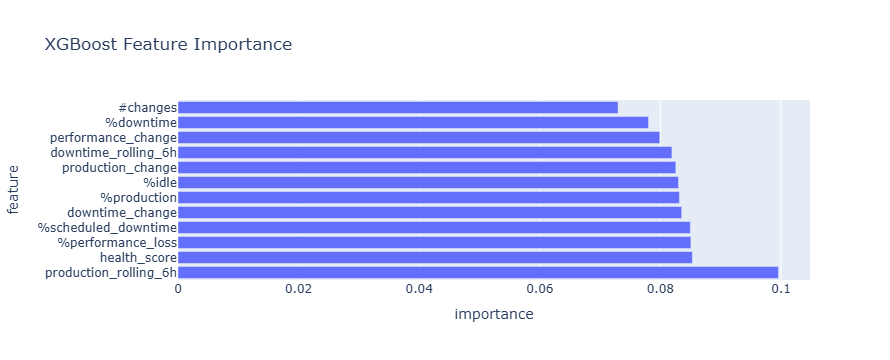

In [82]:
fig = px.bar(
    feature_importance,
    x="importance",
    y="feature",
    orientation="h",
    title="XGBoost Feature Importance"
)

fig.show()

In [83]:
os.makedirs(
    "../data/processed",
    exist_ok=True
)

os.makedirs(
    "../models",
    exist_ok=True
)

In [84]:
test_results.to_csv(
    "../data/processed/risk_results.csv",
    index=False
)

machine_risk_summary.to_csv(
    "../data/processed/machine_risk_summary.csv",
    index=False
)

feature_importance.to_csv(
    "../data/processed/risk_feature_importance.csv",
    index=False
)

print("Risk result files saved successfully.")

Risk result files saved successfully.


In [85]:
joblib.dump(
    {
        "model": risk_model,
        "features": features
    },
    "../models/risk_model.pkl"
)

print(
    "risk_model.pkl saved successfully."
)

risk_model.pkl saved successfully.


In [86]:
print("Final Risk Prediction Summary")
print("=" * 40)

print(
    "Total test records:",
    len(test_results)
)

print(
    "Risk predictions:",
    test_results["risk_prediction"].sum()
)

print(
    "Average risk probability:",
    round(
        test_results["risk_probability"].mean(),
        2
    ),
    "%"
)

print("\nRisk levels:")
print(
    test_results["risk_level"].value_counts()
)

Final Risk Prediction Summary
Total test records: 4670
Risk predictions: 1680
Average risk probability: 45.17 %

Risk levels:
risk_level
MEDIUM      3853
LOW          461
HIGH         355
CRITICAL       1
Name: count, dtype: int64
